### import libraries and dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ast import literal_eval
from collections import Counter
from wordcloud import WordCloud

In [2]:
df = pd.read_csv("datasets/games_cleaned.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89341 entries, 0 to 89340
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   appid                     89341 non-null  int64  
 1   name                      87899 non-null  object 
 2   required_age              89341 non-null  object 
 3   price                     89341 non-null  float64
 4   dlc_count                 89341 non-null  int64  
 5   mac                       89341 non-null  bool   
 6   linux                     89341 non-null  bool   
 7   metacritic_score          89341 non-null  int64  
 8   achievements              89341 non-null  int64  
 9   positive                  89341 non-null  int64  
 10  negative                  89341 non-null  int64  
 11  estimated_owners          89341 non-null  int64  
 12  average_playtime_forever  89341 non-null  int64  
 13  median_playtime_forever   89341 non-null  int64  
 14  discou

### What are the most cited categories?
The *tag* column contains all the categories, i.e., tags that players believe best describe a game. <br>
The *tag* attribute take form of a dictionary of pair (key, count), where key represents a tag, and count represents the number of players believes that tag describes the game. <br> 
The following shows a **wordcloud** of such tags, arranged by the frequencies each tag (!= sum of counts) appeared in the dataset to show which categories of games appear more often according to players<br><br>
The result shows the visual impact of **[singleplayer, indie, action, casual, adventure]** are the most cited tags. This presents a public preference in games genres among the player community 

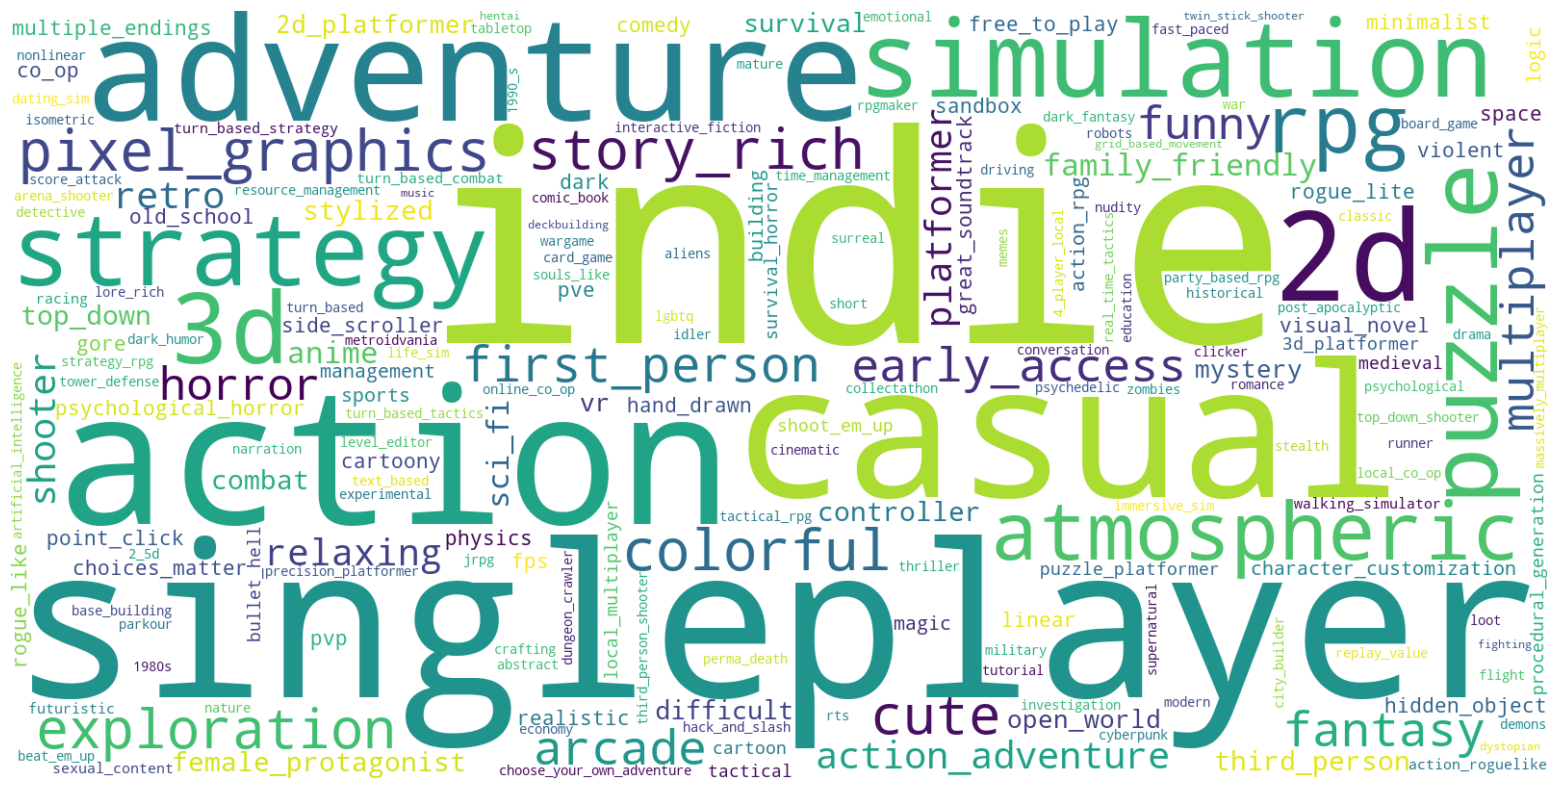

In [3]:
# Count only how often each tag key appears across rows
tag_counter = Counter()

for item in df["tags"]:
    tags_dict = literal_eval(item) if isinstance(item, str) else item
    if isinstance(tags_dict, dict):
        tag_counter.update(tags_dict.keys())  # count keys, not values

# Wordcloud
wc = WordCloud(width=1600, height=800, background_color="white")
wc.generate_from_frequencies(tag_counter)

plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
plt.show()

### Game Graveyard
There are a lot of games with 0 *reviews*, 0 *playtime*, and 0 *peak_ccu* present in the dataset. These are the games that no one has ever played. (1 or 2) out of 3  fields have can have 0-value, they could be an error in the dataset, but all three have 0-values is less probabile so. <br>
The area chart shows the trend of number of games published in each year, while highlighting the number of "dead games". Both show an increasing trend over the year.<br><br>

This signals the increasing size of the gaming market, but also tell us that with the releases of new games, more and more competitions fall out of the attention.

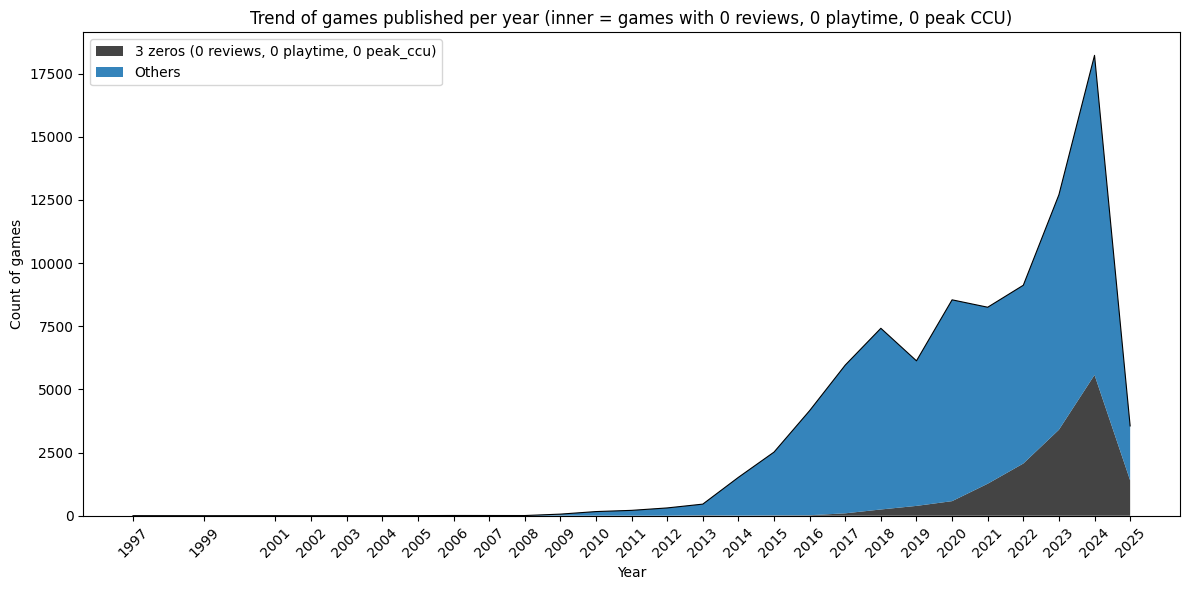

In [4]:
# stacked area: total games per year with inner area = games having 0 reviews, 0 playtime and 0 peak_ccu
total_by_year = df.groupby('year').size().sort_index()
three_zeros = df[(df['num_reviews_total'] == 0) & (df['average_playtime_forever'] == 0) & (df['peak_ccu'] == 0)]
zero_by_year = three_zeros.groupby('year').size().reindex(total_by_year.index, fill_value=0)
others_by_year = total_by_year - zero_by_year

years = total_by_year.index.astype(int)

plt.figure(figsize=(12,6))
plt.stackplot(years,
              zero_by_year.values,
              others_by_year.values,
              labels=['3 zeros (0 reviews, 0 playtime, 0 peak_ccu)', 'Others'],
              colors=['#2f2f2f', '#1f77b4'],
              alpha=0.9)

# outline/top line to emphasize the "others" region
plt.plot(years, zero_by_year.values + others_by_year.values, color='black', lw=0.8)
plt.xlabel('Year')
plt.ylabel('Count of games')
plt.title('Trend of games published per year (inner = games with 0 reviews, 0 playtime, 0 peak CCU)')

# show all year ticks on x-axis
plt.xticks(years, rotation=45)

plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

#### Price influence
he *hypothesis* behind the dead game is that the **game price** has something to do with a game being "dead", higher the price means bigger the investment.<br><br>
The resulting bar chart that groups the dead games into categories show that the price has little to do with the game popularity, since majority of the dead games are free-to-play or under 5 euros. In theory, these games should attract a large gamer base, thanks to the low economic commitment, but the reality is quite the opposite. 

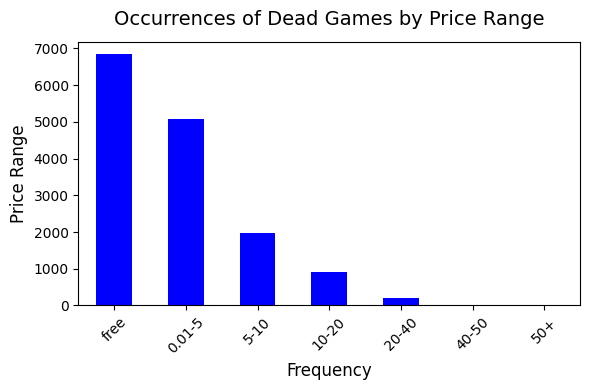

In [30]:
price_zeros = three_zeros['full_price']

# Define bins and labels
bins = [0.0, 0.01, 5, 10, 20, 40, 50, float('inf')]
labels = ['free', '0.01-5', '5-10', '10-20', '20-40', '40-50', '50+']

# Create a series with price values and bin them
price_binned = pd.cut(price_zeros.values, bins=bins, labels=labels, right=False)
price_binned_counts = price_binned.value_counts().sort_index()

ax = price_binned_counts.plot(
    kind='bar',
    figsize=(6, 4),
    color='blue'
)
ax.set_xlabel('Frequency', fontsize=12)
ax.set_ylabel('Price Range', fontsize=12)
ax.set_title('Occurrences of Dead Games by Price Range', fontsize=14, pad=12)
ax.set_xticklabels(labels, rotation=45)

plt.tight_layout()
plt.show()

#### Game curation, measured by *achievements*
Another hypothesis is that *dead games* are not quality-wise complete, that the **developers did not care for the product**. One subtle indicator is the game's number of achievements or trophys. Throphys are a mechanism to encourage players to engage in the games, rewarding for playing and exploring the game mechanics, a way of showing the dedications the developers put into the games. However, this is not an absolute metric for quality game assessment.<br><br>

The resulting stacked bar chart shows that the hypothesis is not necessarily true, games with lower number of achievements are not by default less cared for, at least not statistically so. 

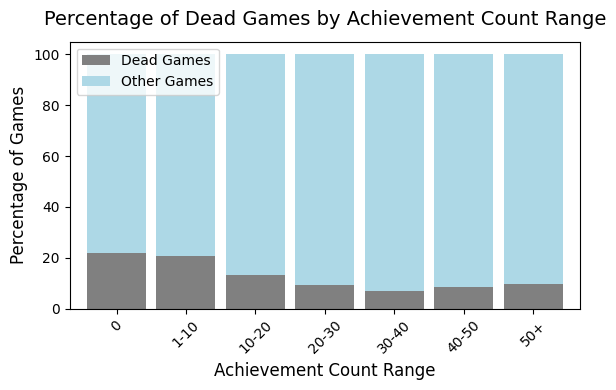

In [41]:
trophy_zeros = three_zeros['achievements']
trophy_all = df['achievements']

bins = [0, 1, 10, 20, 30, 40, 50, float('inf')]
labels = ['0', '1-10', '10-20', '20-30', '30-40', '40-50', '50+']

trophy_binned_zeros = pd.cut(trophy_zeros.values, bins=bins, labels=labels, right=False)
trophy_binned_all = pd.cut(trophy_all.values, bins=bins, labels=labels, right=False)

trophy_binned_zeros_counts = trophy_binned_zeros.value_counts().sort_index()
trophy_binned_all_counts = trophy_binned_all.value_counts().sort_index()

pct_zeros = (trophy_binned_zeros_counts / trophy_binned_all_counts) * 100
pct_others = 100 - pct_zeros

plot = pd.DataFrame({
    'Dead Games': pct_zeros,
    'Other Games': pct_others
})

ax = plot.plot(
    kind = 'bar',
    stacked = True,
    figsize = (6, 4),
    color = ['grey', 'lightblue'],
    width=0.85
)

ax.set_xticklabels(labels, rotation=45)
ax.set_xlabel('Achievement Count Range', fontsize=12)
ax.set_ylabel('Percentage of Games', fontsize=12)
ax.set_title('Percentage of Dead Games by Achievement Count Range', fontsize=14, pad=12)
ax.set_xticklabels(labels, rotation=45)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

#### Genre death
Could the **game genres** have anything to do with being "dead"? It is possible that the common player preferences have shifted. So the *new games* of less popular genres get overlooked.<br><br>

However, the horizontal bar chart did not confirm this hypothesis either, by showing the most frequently appeared genres among dead games, we noticed that there aren't any genre stands out, rather the distribution is almost equal among genres.

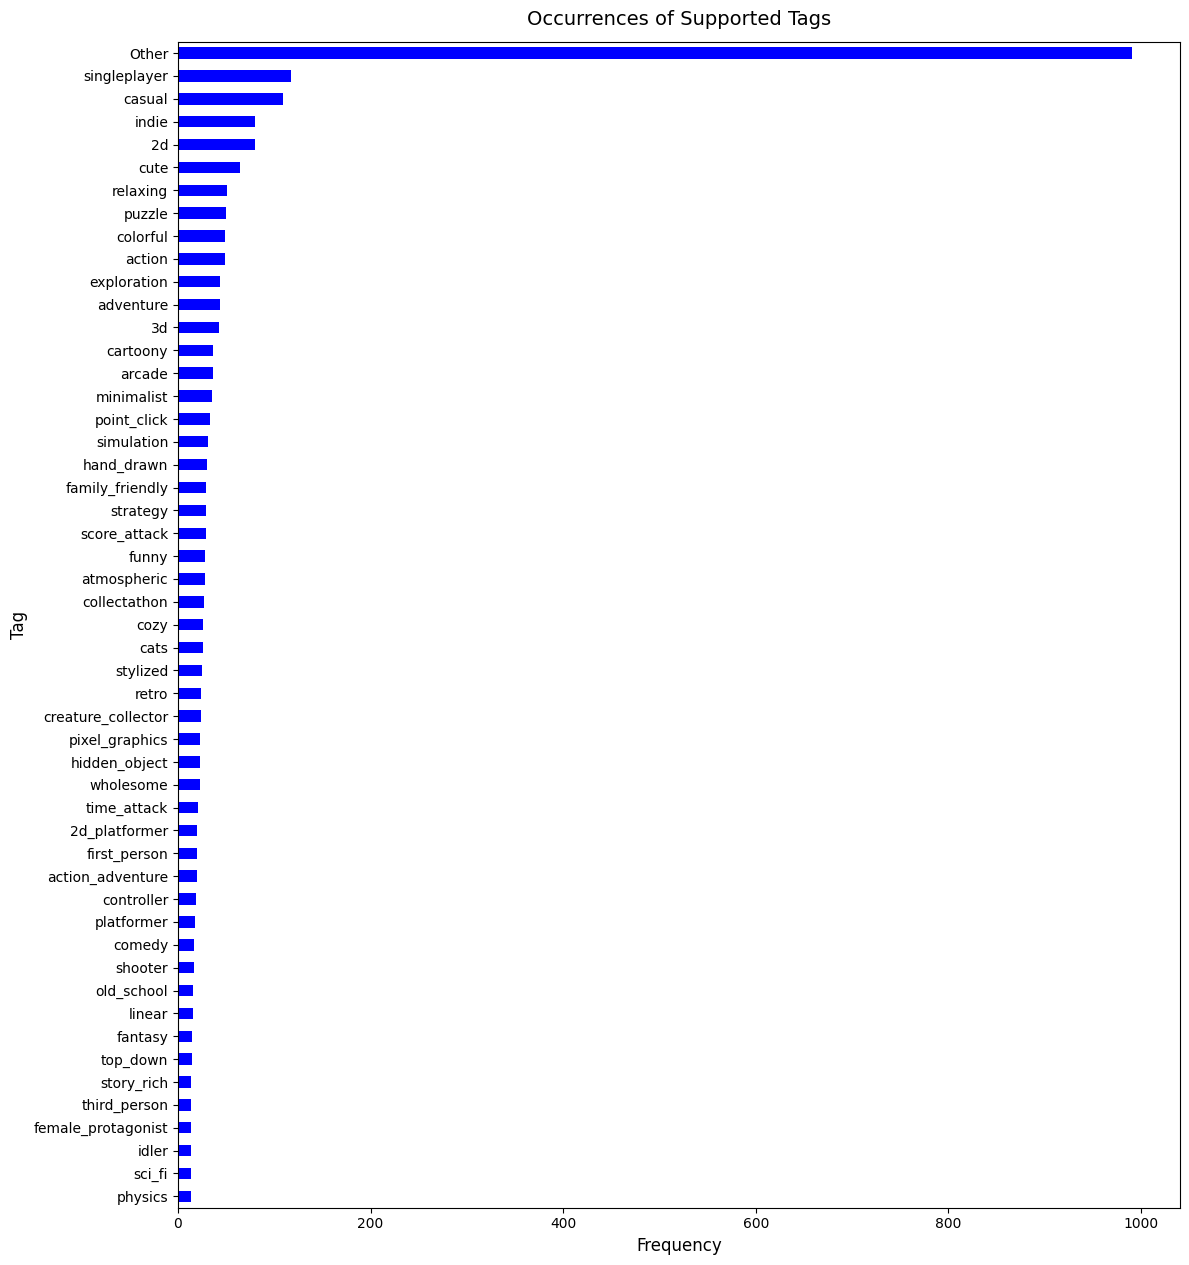

In [42]:
# Count only how often each tag key appears across entries
tag_counter = Counter()

for item in three_zeros['tags']:
    tags_dict = literal_eval(item) if isinstance(item, str) else item
    if isinstance(tags_dict, dict):
        tag_counter.update(tags_dict.keys())  # count keys, not values

tag_counter = pd.Series(tag_counter).sort_values(ascending=False)


max_bars = 50
if len(tag_counter) > max_bars:
    top = tag_counter.head(max_bars).copy()
    top['Other'] = tag_counter.iloc[max_bars:].sum()
else:
    top = tag_counter.copy()
# Create horizontal bar chart

ax = top.sort_values().plot(
    kind='barh',
    figsize=(12, max(6, 0.25 * len(top))),
    color='blue'
)
ax.set_xlabel('Frequency', fontsize=12)
ax.set_ylabel('Tag', fontsize=12)
ax.set_title('Occurrences of Supported Tags', fontsize=14, pad=12)

plt.tight_layout()
plt.show()

#### Final considearion
From the available data, the reasons behind the continue rise of dead games are inconclusive, it is difficult to statistically prove the trend.<br>
However, a possible explaination could be that most of these games are abbandoned project left unfinished, semi-finised, or testing project. Without a price as a possible indicator, they *scream* low-budget and low-quality with no investors behind the project, they do to encourage players to try them out

### Indie game paradox
How does the ease of publishing low-budget games, so called, indie games changed the gaming market?<br>
The area chart shows that the releases of indie games are steady over the year. But at a first sight, it does not seem to disrupt the gaming market with their presence. It showed a steady increse until 2018 when the number saturated, but, they do still represent a big portion of the market, even in 2024. *Remember, the area chart shows the percentage of the indie games against all other genres combined*.<br><br>

Further analysis are needed to confirm the non-disruption

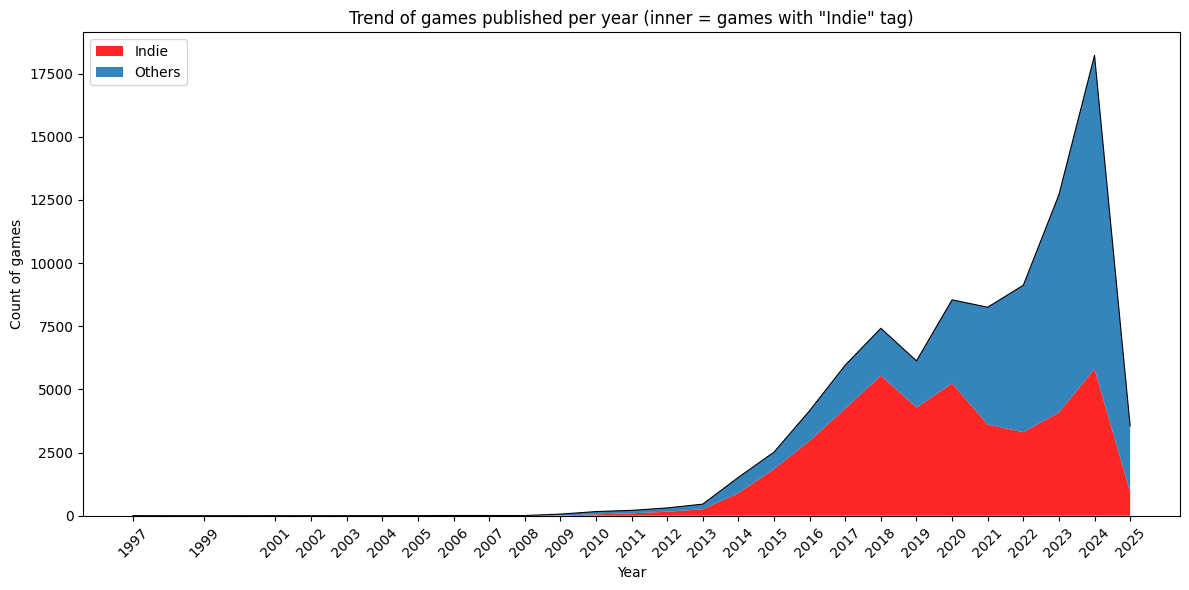

In [ ]:
# count games with 'indie' tag per year
def has_indie(t):
    if isinstance(t, str):
        try:
            d = literal_eval(t)
        except Exception:
            return False
    else:
        d = t
    return isinstance(d, dict) and ("indie" in d)


indie_mask = df["tags"].apply(has_indie)
indie_by_year = (
    df[indie_mask].groupby("year").size().reindex(total_by_year.index, fill_value=0)
)
# total_by_year has been defined in the previous cell
others_by_year = total_by_year - indie_by_year

years = total_by_year.index.astype(int)

plt.figure(figsize=(12, 6))
plt.stackplot(
    years,
    indie_by_year.values,
    others_by_year.values,
    labels=["Indie", "Others"],
    colors=["#ff0e0e", "#1f77b4"],
    alpha=0.9,
)

# outline/top line to emphasize the "others" region
plt.plot(years, indie_by_year.values + others_by_year.values, color="black", lw=0.8)
plt.xlabel("Year")
plt.ylabel("Count of games")
plt.title('Trend of games published per year (inner = games with "Indie" tag)')

# show all year ticks on x-axis
plt.xticks(years, rotation=45)

plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

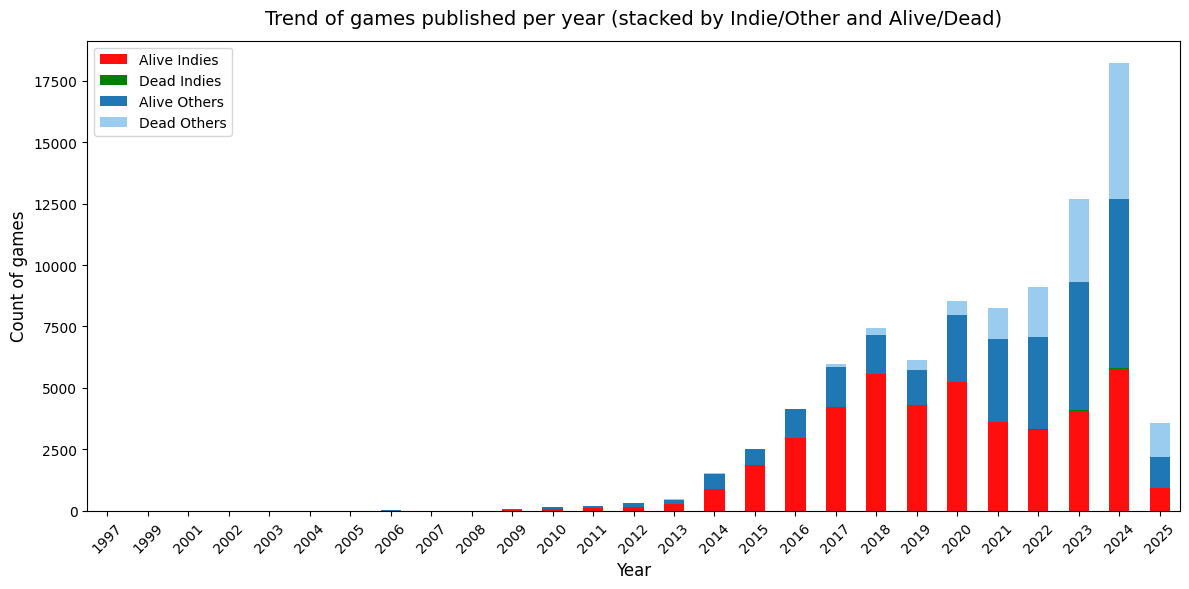

In [68]:
# count dead games with 'indie' tag per year
zero_indie_mask = three_zeros[three_zeros["tags"].apply(has_indie)]
zero_indie_by_year = zero_indie_mask.groupby("year").size().reindex(total_by_year.index, fill_value=0)

alive_indie_by_year = indie_by_year - zero_indie_by_year
zero_others_by_year = zero_by_year - zero_indie_by_year
alive_others_by_year = others_by_year - zero_others_by_year

years = total_by_year.index.astype(int)

plot_indies = pd.DataFrame({
    "Alive Indies": alive_indie_by_year,
    "Dead Indies": zero_indie_by_year,
    "Alive Others": alive_others_by_year,
    "Dead Others": zero_others_by_year,
})

ax = plot_indies.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=["#ff0e0e", "green", "#1f77b4", "#99ccee"],
)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Count of games", fontsize=12)
ax.set_title("Trend of games published per year (stacked by Indie/Other and Alive/Dead)", fontsize=14, pad=12)
ax.set_xticklabels(years, rotation=45)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

#### Game attentions
*What is the effect of the increasing number of games each year to the gaming market, in particular, the indie genre?*<br>
A useful indicator to explore and answer this question is the **median** number of reviews.<br>

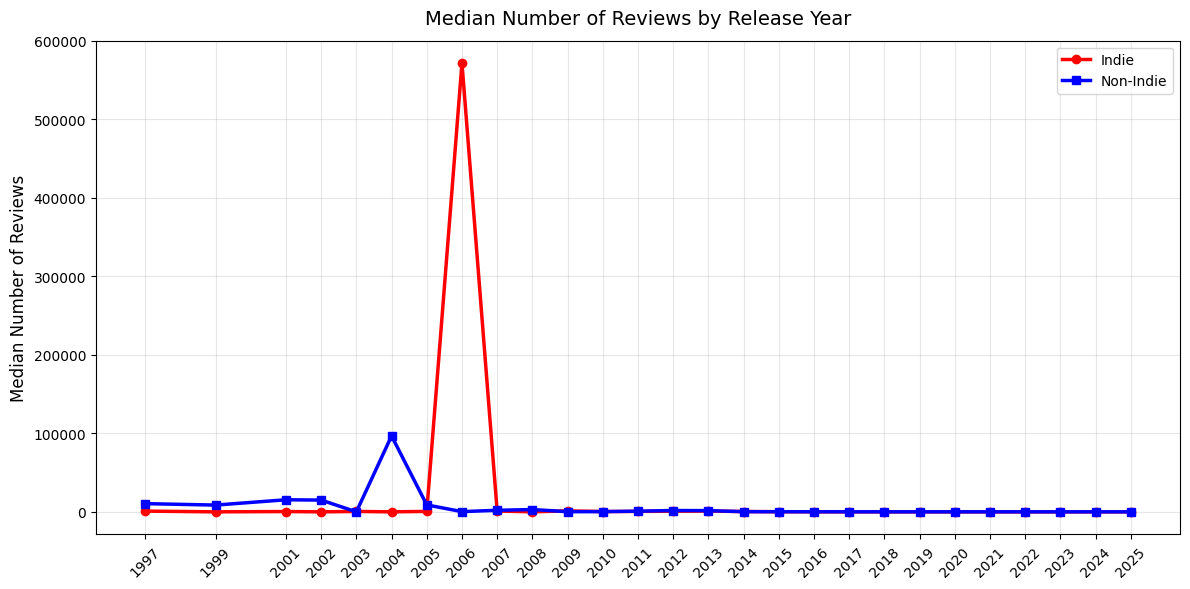

In [ ]:
indie_mask = df[df['tags'].apply(has_indie)]
indie_median_by_year = indie_mask.groupby('year')['num_reviews_total'].median().reindex(total_by_year.index, fill_value=0)

others_mask = df[df['appid'].isin(indie_mask['appid']) == False]
others_median_by_year = others_mask.groupby('year')['num_reviews_total'].median().reindex(total_by_year.index, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))

# Indie
ax.plot(
    indie_median_by_year.index,
    indie_median_by_year.values,
    label='Indie',
    marker='o',
    color='red',
    linewidth=2.5
)

# Non-Indie
ax.plot(
    others_median_by_year.index,
    others_median_by_year.values,
    label='Non-Indie',
    marker='s',
    color='blue',
    linewidth=2.5
)

ax.set_xticks(total_by_year.index.astype(int))
ax.set_ylabel('Median Number of Reviews', fontsize=12)
ax.set_title('Median Number of Reviews by Release Year', fontsize=14, pad=12)

ax.legend()
ax.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

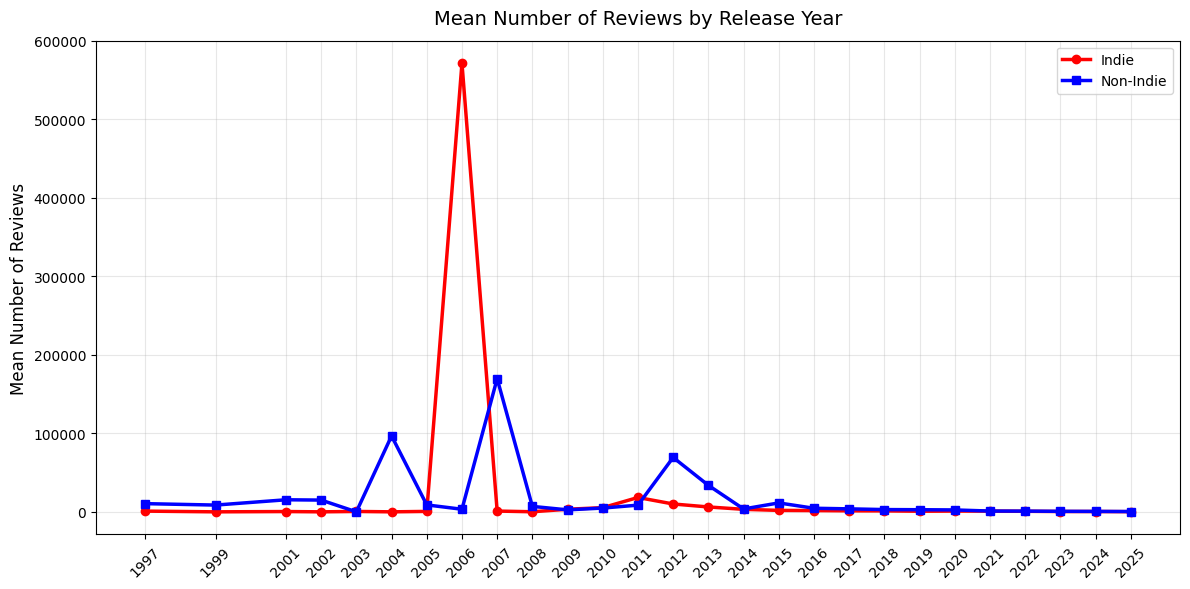

In [102]:
indie_mean_by_year = indie_mask.groupby('year')['num_reviews_total'].mean().reindex(total_by_year.index, fill_value=0)

others_mean_by_year = others_mask.groupby('year')['num_reviews_total'].mean().reindex(total_by_year.index, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))

# Indie
ax.plot(
    indie_mean_by_year.index,
    indie_mean_by_year.values,
    label='Indie',
    marker='o',
    color='red',
    linewidth=2.5
)

# Non-Indie
ax.plot(
    others_mean_by_year.index,
    others_mean_by_year.values,
    label='Non-Indie',
    marker='s',
    color='blue',
    linewidth=2.5
)

ax.set_xticks(total_by_year.index.astype(int))
ax.set_ylabel('Mean Number of Reviews', fontsize=12)
ax.set_title('Mean Number of Reviews by Release Year', fontsize=14, pad=12)

ax.legend()
ax.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()